✅ 사용 가능한 GPU가 감지되었습니다.
GPU 개수: 3개
총 77453개의 JSON 파일을 찾았습니다.
../dataset/Converted_dataset/Fr5_to_DREAM/zed_30779426_left_1748249301.128.json
--------------------------------------------------
Image Path: ../dataset/Fr5/Fr5_6th_250526/top/zed_30779426_left_1748249301.128.jpg
  - 🔗 링크 (Keypoints) 개수: 7개
  - 💪 조인트 (Joints) 개수: 6개
[Reprojection] mean L2 error: 0.000px


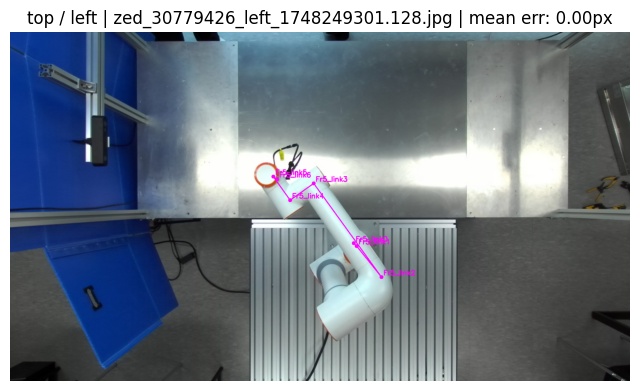

../dataset/Converted_dataset/franka_research3_to_DREAM/zed_41182735_left_1756282038.160.json
--------------------------------------------------
Image Path: ../dataset/franka_research3/franka_research3_pose2/Panda_dataset_20th/view1/zed_41182735_left_1756282038.160.jpg
  - 🔗 링크 (Keypoints) 개수: 9개
  - 💪 조인트 (Joints) 개수: 8개
[Reprojection] mean L2 error: 0.000px


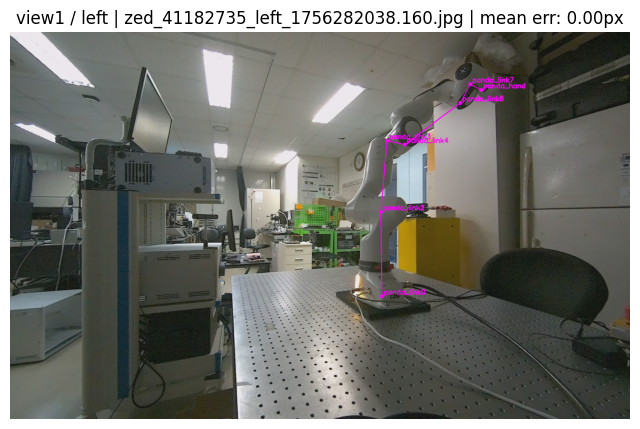

../dataset/Converted_dataset/DREAM_to_DREAM/panda-3cam_realsense/003279.json
--------------------------------------------------
Image Path: ../dataset/DREAM_real/panda-3cam_realsense/panda-3cam_realsense/003279.rgb.jpg
  - 🔗 링크 (Keypoints) 개수: 7개
  - 💪 조인트 (Joints) 개수: 9개
[Reprojection] mean L2 error: 0.000px


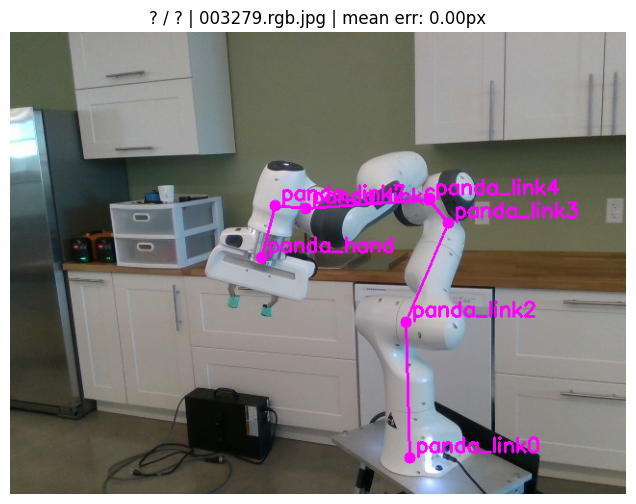

../dataset/Converted_dataset/Fr5_to_DREAM/zed_30779426_left_1748249284.558.json
--------------------------------------------------
Image Path: ../dataset/Fr5/Fr5_6th_250526/top/zed_30779426_left_1748249284.558.jpg
  - 🔗 링크 (Keypoints) 개수: 7개
  - 💪 조인트 (Joints) 개수: 6개
[Reprojection] mean L2 error: 0.000px


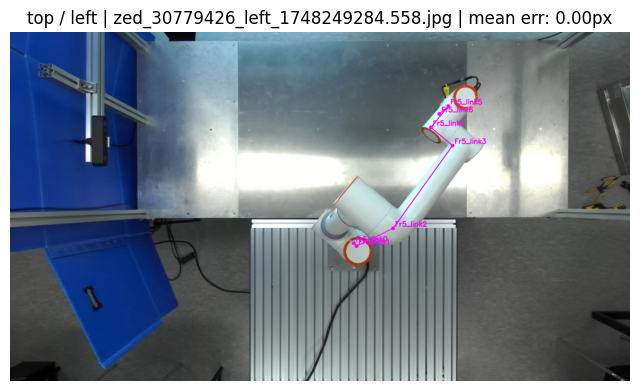

../dataset/Converted_dataset/Fr5_to_DREAM/zed_38007749_right_1748249175.070.json
--------------------------------------------------
Image Path: ../dataset/Fr5/Fr5_5th_250526/left/zed_38007749_right_1748249175.070.jpg
  - 🔗 링크 (Keypoints) 개수: 7개
  - 💪 조인트 (Joints) 개수: 6개
[Reprojection] mean L2 error: 0.000px


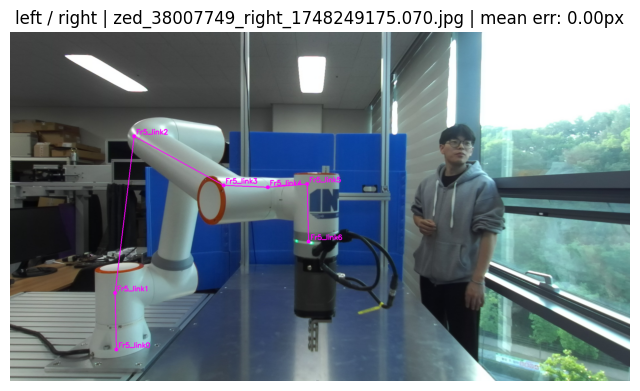

In [6]:
import os
import glob
import json
import numpy as np
import random
import wandb
import threading
import time
import cv2
import math
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm 

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR # 상단에 추가
import kornia.augmentation as K

from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"
is_available = torch.cuda.is_available()

if is_available:
    # 2. 사용 가능한 GPU 개수 확인
    gpu_count = torch.cuda.device_count()
    print(f"✅ 사용 가능한 GPU가 감지되었습니다.")
    print(f"GPU 개수: {gpu_count}개")

# 검색을 시작할 최상위 폴더 경로
search_dir = "../dataset/Converted_dataset"  # <-- 이곳에 실제 폴더 경로를 입력하세요.
json_files = glob.glob(os.path.join(search_dir, '**', '*.json'), recursive=True)

print(f"총 {len(json_files)}개의 JSON 파일을 찾았습니다.")

def load_sample(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        sample = json.load(f)
    obj = sample["objects"][0]
    meta = sample["meta"]
    sim_state = sample["sim_state"]
    return obj, meta, sim_state

def project_camframe_points(pts_cam, K, dist):
    """카메라 프레임 3D -> 픽셀 (extrinsic = I)"""
    rvec = np.zeros((3,1), np.float64)
    tvec = np.zeros((3,1), np.float64)
    pts = np.asarray(pts_cam, dtype=np.float64).reshape(-1,1,3)
    K = np.asarray(K, dtype=np.float64)
    dist = np.asarray(dist, dtype=np.float64)
    img_pts, _ = cv2.projectPoints(pts, rvec, tvec, K, dist)
    return img_pts.reshape(-1,2)

# 링크와 조인트 개수를 출력하는 기능을 추가합니다.
def visualize_json(json_path, show_ids=True, compute_reproj_error=True, point_radius=6, thickness=2):
    # 수정된 load_sample 함수를 호출합니다.
    obj, meta, sim_state = load_sample(json_path)
    
    image_path = meta["image_path"]
    
    # 링크와 조인트 개수를 계산합니다.
    num_keypoints = len(obj.get("keypoints", []))
    num_joints = len(sim_state.get("joints", []))
    
    # 계산된 정보를 출력합니다.
    print("-" * 50)
    print(f"Image Path: {image_path}")
    print(f"  - 🔗 링크 (Keypoints) 개수: {num_keypoints}개")
    print(f"  - 💪 조인트 (Joints) 개수: {num_joints}개")
    
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # 이미지 로드
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 키포인트(픽셀) 수집
    names = []
    uv_from_json = []
    cam3d = []
    for kp in obj["keypoints"]:
        names.append(kp["name"])
        uv_from_json.append(kp["projected_location"])
        cam3d.append(kp["location"])
    uv_from_json = np.asarray(uv_from_json, dtype=np.float64)
    cam3d = np.asarray(cam3d, dtype=np.float64)

    # 재투영 (옵션)
    reproj_errs = None
    if compute_reproj_error and cam3d.size > 0:
        K = meta["K"]
        dist = meta.get("dist_coeffs", np.zeros(5))
        uv_reproj = project_camframe_points(cam3d, K, dist)
        reproj_errs = np.linalg.norm(uv_reproj - uv_from_json, axis=1)
        mean_err = float(reproj_errs.mean())
        print(f"[Reprojection] mean L2 error: {mean_err:.3f}px")

    # 드로잉
    overlay = img_rgb.copy()
    color = (255, 0, 255)  # magenta
    for i, (u, v) in enumerate(uv_from_json.astype(int)):
        cv2.circle(overlay, (u, v), point_radius, color, -1)
        if show_ids:
            label = f"{names[i]}"
            cv2.putText(overlay, label, (u + 6, v - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, thickness)

        if i > 0:
            u_prev, v_prev = uv_from_json[i-1].astype(int)
            cv2.line(overlay, (u_prev, v_prev), (u, v), color, thickness)

    title = f"{meta.get('view','?')} / {meta.get('cam','?')} | {os.path.basename(image_path)}"
    if reproj_errs is not None:
        title += f" | mean err: {reproj_errs.mean():.2f}px"

    plt.figure(figsize=(8, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(title)
    plt.show()

# 메인 실행 부분은 변경 없이 그대로 사용합니다.
random_samples = random.sample(json_files, 5)
for file_path in random_samples:
    print(file_path)
    visualize_json(file_path)

In [12]:
def create_gt_heatmap(keypoint_2d, heatmap_size, sigma):
    H, W = heatmap_size
    x, y = keypoint_2d
    xx, yy = np.meshgrid(np.arange(W), np.arange(H))
    dist_sq = (xx - x)**2 + (yy - y)**2
    heatmap = np.exp(-dist_sq / (2 * sigma**2))
    heatmap[heatmap < np.finfo(float).eps * heatmap.max()] = 0
    return heatmap

def _scale_points(points_xy, from_size, to_size):
    Wf, Hf = from_size
    Wt, Ht = to_size
    out = np.empty_like(points_xy, dtype=np.float32)
    out[:, 0] = points_xy[:, 0] * (Wt / float(Wf))
    out[:, 1] = points_xy[:, 1] * (Ht / float(Hf))
    return out

class RobotPoseDataset(Dataset):
    def __init__(self, json_files, transform, sigma=5.0):
        self.json_files = json_files
        self.transform = transform
        self.sigma = sigma

    def __len__(self):
        return len(self.json_files)

    def __getitem__(self, idx):
        json_path = self.json_files[idx]

        with open(json_path, "r", encoding="utf-8") as f:
            sample = json.load(f)
        
        ###-------------- 이미지 관련 -------------###
        image_path = sample['meta']['image_path']
        img_bgr = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        img_pil = Image.fromarray(img_rgb)
        image_dict = self.transform(img_pil)

        ###-------------- 히트맵 관련 -------------###
        Ht, Wt = (224, 224)
        keypoints = sample["objects"][0]["keypoints"]
        joint_num = len(keypoints)
        kpts_2d_orig = np.array([kp["projected_location"] for kp in keypoints])

        kpts_on_heatmap = _scale_points(kpts_2d_orig, from_size=(w, h), to_size=(Wt, Ht))
        heatmaps_np = np.zeros((joint_num, Ht, Wt), dtype=np.float32)
        for joint in range(joint_num):
            heatmaps_np[joint] = create_gt_heatmap(kpts_on_heatmap[joint], (Ht, Wt), self.sigma)
        gt_heatmaps_dict = torch.from_numpy(heatmaps_np)

        ###-------------- 관절각도 관련 -------------###
        angles = []
        for angle in sample['sim_state']["joints"]:
            angles.append(angle["position"])
        gt_angles = torch.tensor(angles, dtype=torch.float32)
        return image_dict, gt_heatmaps_dict, gt_angles

###----------- 관절개수 패딩 관련 -------------###
def robot_collate_fn_fixed(batch):
    images, heatmaps, angles = zip(*batch)
    images = torch.stack(images, 0)

    MAX_JOINTS = 9
    MAX_ANGLES = 9

    heatmaps_padded = torch.zeros(len(heatmaps), MAX_JOINTS, heatmaps[0].shape[1], heatmaps[0].shape[2])
    angles_padded = torch.zeros(len(angles), MAX_ANGLES)
    
    lengths = []
    for i, (h, a) in enumerate(zip(heatmaps, angles)):
        num_joints = h.shape[0]
        lengths.append(num_joints)
        heatmaps_padded[i, :num_joints, :, :] = h
        angles_padded[i, :a.shape[0]] = a

    lengths = torch.tensor(lengths, dtype=torch.long)
    return images, heatmaps_padded, angles_padded, lengths

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

full_dataset = RobotPoseDataset(json_files, transform, sigma=5.0)
val_ratio = 0.2
total_size = len(full_dataset)
val_size = int(total_size * val_ratio)
train_size = total_size - val_size

torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"✅ 데이터셋 분리 완료:")
print(f"  - 전체 데이터: {total_size}개")
print(f"  - 학습 데이터: {len(train_dataset)}개")
print(f"  - 검증 데이터: {len(val_dataset)}개")

BATCH_SIZE = 16 # 배치 사이즈 설정
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # 학습 데이터는 섞어줌
    num_workers=8,
    pin_memory=True,
    collate_fn=robot_collate_fn_fixed
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # 검증 데이터는 섞을 필요 없음
    num_workers=8,
    pin_memory=True,
    collate_fn=robot_collate_fn_fixed
)

# ======================= DataLoader 확인 =======================
print("\n✅ Train DataLoader 샘플 확인:")
img_tensors, heatmap_tensors, angle_tensors, lengths = next(iter(train_loader))
print(f"  - Image tensor shape:   {img_tensors.shape}")
print(f"  - Heatmap tensor shape: {heatmap_tensors.shape}")
print(f"  - Angle tensor shape:   {angle_tensors.shape}")

print("\n✅ Validation DataLoader 샘플 확인:")
img_tensors, heatmap_tensors, angle_tensors, lengths = next(iter(val_loader))
print(f"  - Image tensor shape:   {img_tensors.shape}")
print(f"  - Heatmap tensor shape: {heatmap_tensors.shape}")
print(f"  - Angle tensor shape:   {angle_tensors.shape}")

✅ 데이터셋 분리 완료:
  - 전체 데이터: 77453개
  - 학습 데이터: 61963개
  - 검증 데이터: 15490개

✅ Train DataLoader 샘플 확인:


  - Image tensor shape:   torch.Size([16, 3, 512, 512])
  - Heatmap tensor shape: torch.Size([16, 9, 224, 224])
  - Angle tensor shape:   torch.Size([16, 9])

✅ Validation DataLoader 샘플 확인:
  - Image tensor shape:   torch.Size([16, 3, 512, 512])
  - Heatmap tensor shape: torch.Size([16, 9, 224, 224])
  - Angle tensor shape:   torch.Size([16, 9])


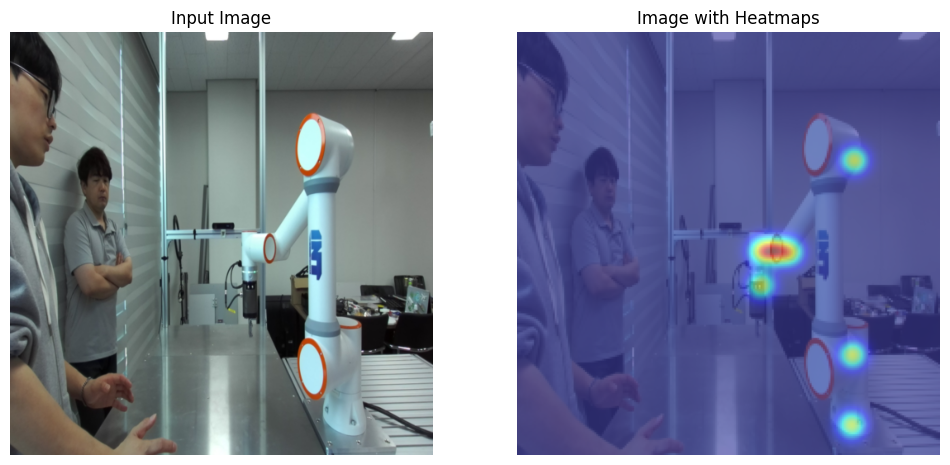

In [13]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

def denormalize(tensor, mean, std):
    """텐서를 역정규화하여 이미지로 복원합니다."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# 배치에서 첫 번째 데이터 가져오기
img_to_show = img_tensors[0]
heatmap_to_show = heatmap_tensors[0]

# 이미지 역정규화 및 채널 순서 변경 (C, H, W) -> (H, W, C)
img_to_show = denormalize(img_to_show.clone(), mean, std)
img_np = img_to_show.numpy().transpose(1, 2, 0)
img_np = np.clip(img_np, 0, 1) # 값 범위를 [0, 1]로 유지
img_resize = cv2.resize(img_np, (224,224))
# 모든 히트맵을 하나로 합쳐서 시각화
combined_heatmap = torch.sum(heatmap_to_show, dim=0).numpy()

# 시각화
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_resize, alpha=0.7)
plt.imshow(combined_heatmap, cmap='jet', alpha=0.5) # 이미지 위에 히트맵 겹치기
plt.title("Image with Heatmaps")
plt.axis('off')

plt.show()

In [ ]:
MODEL_NAME = 'facebook/dinov3-vitl16-pretrain-lvd1689m'
FEATURE_DIM = 512
NUM_ANGLES = 9
NUM_JOINTS = 9

class DINOv3Backbone(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)

    def forward(self, image_tensor_batch):
        with torch.no_grad():
            outputs = self.model(pixel_values=image_tensor_batch)
        tokens = outputs.last_hidden_state
        num_reg = int(getattr(self.model.config, "num_register_tokens", 0))
        patch_tokens = tokens[:, 1 + num_reg :, :]  # (B, N_patches, D)
        return patch_tokens

class JointAngleHead(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, num_angles=NUM_ANGLES, num_queries=4, nhead=8, num_decoder_layers=2):
        super().__init__()
        
        self.pose_queries = nn.Parameter(torch.randn(1, num_queries, input_dim))
    
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=input_dim, 
            nhead=nhead, 
            dim_feedforward=input_dim * 4, # 일반적인 설정
            dropout=0.1, 
            activation='gelu',
            batch_first=True  # (batch, seq, feature) 입력을 위함
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.angle_predictor = nn.Sequential(
            nn.LayerNorm(input_dim * num_queries),
            nn.Linear(input_dim * num_queries, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Linear(256, num_angles)
        )
    
    def forward(self, fused_features):
        b = fused_features.size(0)
        queries = self.pose_queries.repeat(b, 1, 1)
        attn_output = self.transformer_decoder(tgt=queries, memory=fused_features)
        output_flat = attn_output.flatten(start_dim=1)
        return self.angle_predictor(output_flat)

class TokenFuser(nn.Module):
    """
    ViT의 패치 토큰(1D 시퀀스)을 CNN이 사용하기 좋은 2D 특징 맵으로 변환하고 정제합니다.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.refine_blocks = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        # x: (B, D, H, W) 형태로 reshape된 토큰 맵
        projected = self.projection(x)
        refined = self.refine_blocks(projected)
        residual = self.residual_conv(x)
        return torch.nn.functional.gelu(refined + residual)

class LightCNNStem(nn.Module):
    """
    UNet의 인코더처럼 고해상도의 공간적 특징(shallow features)을 
    여러 스케일로 추출하기 위한 경량 CNN.
    """
    def __init__(self):
        super().__init__()
        # 간단한 CNN 블록 구성
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/2
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/4
            nn.BatchNorm2d(32),
            nn.GELU()
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False), # 해상도 1/8
            nn.BatchNorm2d(64),
            nn.GELU()
        )
        
    def forward(self, x):
        # x: 원본 이미지 텐서 배치 (B, 3, H, W)
        feat_4 = self.conv_block1(x)  # 1/4 스케일 특징
        feat_8 = self.conv_block2(feat_4) # 1/8 스케일 특징
        return feat_4, feat_8 # 다른 해상도의 특징들을 반환

class FusedUpsampleBlock(nn.Module):
    """
    업샘플링된 특징과 CNN 스템의 고해상도 특징(스킵 연결)을 융합하는 블록.
    """
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.refine_conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x, skip_feature):
        x = self.upsample(x)
        
        # skip_feature를 x의 크기에 강제로 맞춥니다.
        # ----------------------------------------------------------------------
        # 두 텐서의 높이와 너비가 다를 경우, skip_feature를 x의 크기로 리사이즈합니다.
        if x.shape[-2:] != skip_feature.shape[-2:]:
            skip_feature = F.interpolate(
                skip_feature, 
                size=x.shape[-2:], # target H, W
                mode='bilinear', 
                align_corners=False
            )
        fused = torch.cat([x, skip_feature], dim=1)
        return self.refine_conv(fused)

class UNetViTKeypointHead(nn.Module):
    def __init__(self, input_dim=768, num_joints=NUM_JOINTS, heatmap_size=(224, 224)):
        super().__init__()
        self.heatmap_size = heatmap_size
        self.token_fuser = TokenFuser(input_dim, 256)
        self.decoder_block1 = FusedUpsampleBlock(in_channels=256, skip_channels=64, out_channels=128)
        self.decoder_block2 = FusedUpsampleBlock(in_channels=128, skip_channels=32, out_channels=64)
        self.final_upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.heatmap_predictor = nn.Conv2d(64, num_joints, kernel_size=3, padding=1)

    def forward(self, dino_features, cnn_features):
        cnn_feat_4, cnn_feat_8 = cnn_features
        num_patches_to_keep = 196
        dino_features_sliced = dino_features[:, :num_patches_to_keep, :]
        
        b, n, d = dino_features_sliced.shape
        h = w = int(n**0.5)
        x = dino_features_sliced.permute(0, 2, 1).reshape(b, d, h, w)

        x = self.token_fuser(x)
        x = self.decoder_block1(x, cnn_feat_8)
        x = self.decoder_block2(x, cnn_feat_4)
        x = self.final_upsample(x)
        heatmaps = self.heatmap_predictor(x)
        
        return F.interpolate(heatmaps, size=self.heatmap_size, mode='bilinear', align_corners=False)
        
class DINOv3PoseEstimator(nn.Module):
    def __init__(self, dino_model_name=MODEL_NAME):
        super().__init__()
        self.backbone = DINOv3Backbone(dino_model_name)
        feature_dim = self.backbone.model.config.hidden_size
        self.cnn_stem = LightCNNStem() # 경량 CNN 스템 추가
        self.keypoint_head = UNetViTKeypointHead(input_dim=feature_dim) # 새로운 UNet-ViT 헤드
        self.angle_head = JointAngleHead(input_dim=feature_dim)      # 기존 Attention 헤드

    def forward(self, image_tensor_batch):
        dino_features = self.backbone(image_tensor_batch)      # 의미 정보
        cnn_stem_features = self.cnn_stem(image_tensor_batch) # 공간 정보
        predicted_heatmaps = self.keypoint_head(dino_features, cnn_stem_features)
        predicted_angles = self.angle_head(dino_features)
        
        return predicted_heatmaps, predicted_angles

In [ ]:
# 하이퍼파라미터
LEARNING_RATE = 1e-4
BATCH_SIZE = 16
EPOCHS = 100
VAL_RATIO = 0.2
WANDB_PROJECT = "DINOv3_Pose_Estimation"

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Wandb 초기화
wandb.init(
    project="robot-pose-estimation_New", 
    config={"learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,}, 
    name=f"run_{time.strftime('%Y%m%d_%H%M%S')}")

model = DINOv3PoseEstimator().to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

loss_fn_heatmap = nn.MSELoss(reduction='none') # 마스킹을 위해 reduction='none'
loss_fn_angle = nn.MSELoss(reduction='none')

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

heatmap_loss_weight = 1.0
angle_loss_weight = 0.5

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # --- 학습 단계 ---
    model.train()
    train_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, gt_heatmaps, gt_angles, lengths in pbar:
        images = images.to(device)
        gt_heatmaps = gt_heatmaps.to(device)
        gt_angles = gt_angles.to(device)
        lengths = lengths.to(device)

        pred_heatmaps, pred_angles = model(images)
        
        # --- 마스크 생성 및 손실 계산 ---
        # 1. 마스크 생성: 실제 관절 수만큼만 True (1)
        mask_angle = torch.arange(gt_angles.shape[1], device=device)[None, :] < lengths[:, None]
        mask_heatmap = mask_angle[:, :, None, None].expand_as(gt_heatmaps)
        
        # 2. 마스킹된 손실 계산
        loss_h = loss_fn_heatmap(pred_heatmaps, gt_heatmaps)
        loss_h = (loss_h * mask_heatmap).sum() / mask_heatmap.sum() # True인 부분의 평균
        
        loss_a = loss_fn_angle(pred_angles, gt_angles)
        loss_a = (loss_a * mask_angle).sum() / mask_angle.sum()
        
        # 3. 최종 가중합 손실
        total_loss = (heatmap_loss_weight * loss_h) + (angle_loss_weight * loss_a)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        train_loss += total_loss.item()
        pbar.set_postfix(loss=total_loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- 검증 단계 ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, gt_heatmaps, gt_angles, lengths in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images = images.to(device)
            gt_heatmaps = gt_heatmaps.to(device)
            gt_angles = gt_angles.to(device)
            
            pred_heatmaps, pred_angles = model(images)
            
            mask_angle = torch.arange(gt_angles.shape[1], device=device)[None, :] < lengths[:, None]
            mask_heatmap = mask_angle[:, :, None, None].expand_as(gt_heatmaps)
            
            loss_h = (loss_fn_heatmap(pred_heatmaps, gt_heatmaps) * mask_heatmap).sum() / mask_heatmap.sum()
            loss_a = (loss_fn_angle(pred_angles, gt_angles) * mask_angle).sum() / mask_angle.sum()
            
            total_loss = (heatmap_loss_weight * loss_h) + (angle_loss_weight * loss_a)
            val_loss += total_loss.item()

    avg_val_loss = val_loss / len(val_loader)
    
    scheduler.step()

    wandb.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "learning_rate": scheduler.get_last_lr()[0]
    })

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

    # ======================= 5. 모델 저장 =======================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        os.makedirs("checkpoints", exist_ok=True)
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(model_to_save.state_dict(), f"checkpoints/best_model_epoch_{epoch+1}.pth")
        print(f"✨ New best model saved with validation loss: {best_val_loss:.6f}")

wandb.finish()
print("🎉 Training finished.")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 1/100 [Train]:   0%|          | 0/3873 [00:00<?, ?it/s]

[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029


Epoch 1/100 [Train]:   0%|          | 1/3873 [00:02<2:23:37,  2.23s/it, loss=1.19e+3]

[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029


...

[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029
[DINOv3Backbone] num_register_tokens = 4, total tokens = 1029


Epoch 1/100 [Train]:   0%|          | 6/3873 [00:07<1:17:06,  1.20s/it, loss=286]
socket.send() raised exception.
socket.send() raised exception.


KeyboardInterrupt: 

socket.send() raised exception.
socket.send() raised exception.


socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.s